In [ ]:
import pandas as pd

file_path = 'TataGlobal_Ltd.csv'
data = pd.read_csv(file_path)

data.head()

,Date,Open,High,Low,Last,Close,Total Trade Quantity,Turnover (Lacs)
0,2018-10-08,208.00,222.25,206.85,216.00,215.15,4642146.0,10062.83
1,2018-10-05,217.00,218.60,205.90,210.25,209.20,3519515.0,7407.06
2,2018-10-04,223.50,227.80,216.15,217.25,218.20,1728786.0,3815.79
3,2018-10-03,230.00,237.50,225.75,226.45,227.60,1708590.0,3960.27
4,2018-10-01,234.55,234.60,221.05,230.30,230.90,1534749.0,3486.05


In [ ]:
data = pd.DataFrame({
    'date_column': ['2025-02-05', '2025-02-06', '2025-02-07']
})

# Convert to datetime and keep only date part
data['date'] = pd.to_datetime(data['date_column']).dt.date

print(data)

  date_column        date
0  2025-02-05  2025-02-05
1  2025-02-06  2025-02-06
2  2025-02-07  2025-02-07


In [ ]:
import pandas as pd

# Load your dataset (replace with your actual file path)
data = pd.read_csv('TataGlobal_Ltd.csv')

# Check the columns to confirm available date columns
print("Columns in DataFrame:", data.columns.tolist())

# Strip any leading/trailing spaces from column names
data.columns = data.columns.str.strip()

# Convert the appropriate date column to datetime format if it exists
if 'Date' in data.columns: # Use 'date' or 'date_column' based on your DataFrame
    data['Date'] = pd.to_datetime(data['Date'], utc=True)
else:
    print("The 'date' column is not found in the DataFrame.")

# Set the 'date' column as the index of the DataFrame
data.set_index('Date', inplace=True)

# Check for missing values
missing_values = data.isnull().sum()
print("Missing Values:\n", missing_values)

# Drop specific columns that are not needed
data_cleaned = data.drop(columns=['Total Trade Quantity', 'Turnover (Lacs)'], errors='ignore')

# Display information about the cleaned DataFrame
data_cleaned.info()

# Optionally, display the first few rows of the cleaned DataFrame
print(data_cleaned.head())

Columns in DataFrame: ['Date', 'Open', 'High', 'Low', 'Last', 'Close', 'Total Trade Quantity', 'Turnover (Lacs)']
Missing Values:
 Open                    0
High                    0
Low                     0
Last                    0
Close                   0
Total Trade Quantity    0
Turnover (Lacs)         0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1235 entries, 2018-10-08 00:00:00+00:00 to 2013-10-08 00:00:00+00:00
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    1235 non-null   float64
 1   High    1235 non-null   float64
 2   Low     1235 non-null   float64
 3   Last    1235 non-null   float64
 4   Close   1235 non-null   float64
dtypes: float64(5)
memory usage: 57.9 KB
                             Open    High     Low    Last   Close
Date                                                             
2018-10-08 00:00:00+00:00  208.00  222.25  206.85  216.00  215.15
2018-10-05 00:00:00+00

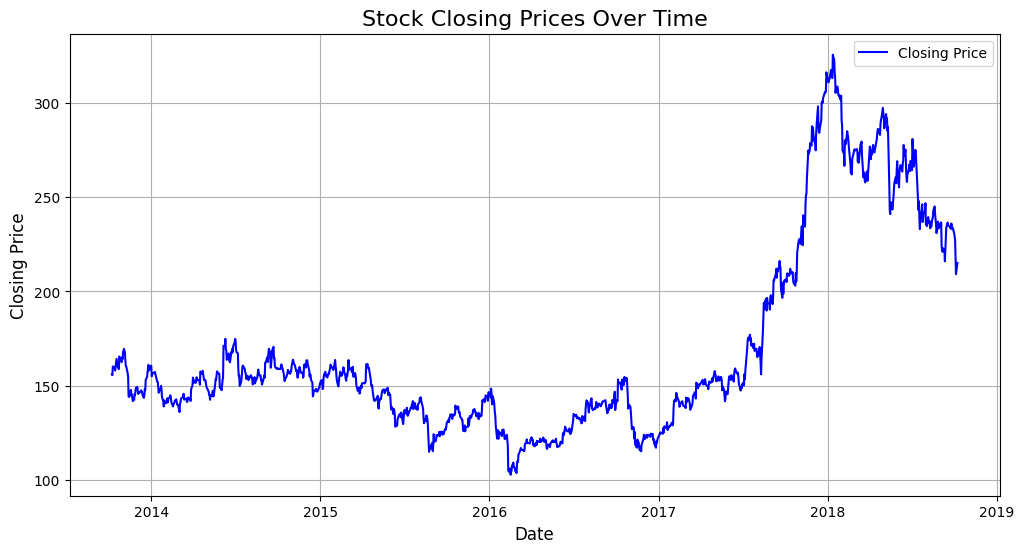

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(data_cleaned['Close'], label='Closing Price', color='blue')
plt.title('Stock Closing Prices Over Time', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Closing Price', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaled_data = pd.DataFrame(
    scaler.fit_transform(data_cleaned),
    index=data_cleaned.index,
    columns=data_cleaned.columns
)

scaled_data['7-Day MA'] = scaled_data['Close'].rolling(window=7).mean()

scaled_data = scaled_data.dropna()

scaled_data.head()

,Open,High,Low,Last,Close,7-Day MA
Date,,,,,,
2018-09-27 00:00:00+00:00,0.585447,0.589784,0.591473,0.587419,0.585388,0.543959
2018-09-26 00:00:00+00:00,0.609702,0.604060,0.597789,0.592792,0.589870,0.556189
2018-09-25 00:00:00+00:00,0.579884,0.589561,0.595533,0.598388,0.598162,0.573414
2018-09-24 00:00:00+00:00,0.580997,0.600491,0.589894,0.588314,0.585612,0.583083
2018-09-21 00:00:00+00:00,0.587450,0.590676,0.577261,0.587195,0.591439,0.587565


In [ ]:
from sklearn.preprocessing import MinMaxScaler
import joblib

scaler = MinMaxScaler()
scaler.fit(data_cleaned)
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [ ]:
from sklearn.model_selection import train_test_split

X = scaled_data.drop(columns=['Close'])
y = scaled_data['Close']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=40, shuffle=False)

print("Training feature set shape:", X_train.shape)
print("Testing feature set shape:", X_test.shape)
print("Training target set shape:", y_train.shape)
print("Testing target set shape:", y_test.shape)


Training feature set shape: (860, 5)
Testing feature set shape: (369, 5)
Training target set shape: (860,)
Testing target set shape: (369,)


In [ ]:
scaled_data['7-Day MA'] = scaled_data['Close'].rolling(window=7).mean()
scaled_data = scaled_data.dropna()
scaled_data.head()

from sklearn.model_selection import train_test_split
X = scaled_data.drop(columns=['Close'])
y = scaled_data['Close']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=40, shuffle=False)
print("Training feature set shape:", X_train.shape)
print("Testing feature set shape:", X_test.shape)
print("Training target set shape:", y_train.shape)
print("Testing target set shape:", y_test.shape)

from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import mean_squared_error, r2_score

linear_model = LinearRegression()
lasso_model = Lasso(alpha=0.00001)

linear_model.fit(X_train, y_train)
lasso_model.fit(X_train, y_train) # lasso is used to find the coefficients to minimize the error sum of sqr

y_pred_linear = linear_model.predict(X_test)
y_pred_lasso = lasso_model.predict(X_test)

linear_mse = mean_squared_error(y_test, y_pred_linear)
lasso_mse = mean_squared_error(y_test, y_pred_lasso)
linear_r2 = r2_score(y_test, y_pred_linear)
lasso_r2 = r2_score(y_test, y_pred_lasso)

print("Linear Regression - MSE:", linear_mse, "R2:", linear_r2)
print("Lasso Regression - MSE:", lasso_mse, "R2:", lasso_r2)

Training feature set shape: (978, 5)
Testing feature set shape: (245, 5)
Training target set shape: (978,)
Testing target set shape: (245,)
Linear Regression - MSE: 2.4622241956409584e-06 R2: 0.9984271621313053
Lasso Regression - MSE: 5.111525216517309e-06 R2: 0.9967348219380026


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.123e-02, tolerance: 6.328e-03
  model = cd_fast.enet_coordinate_descent(


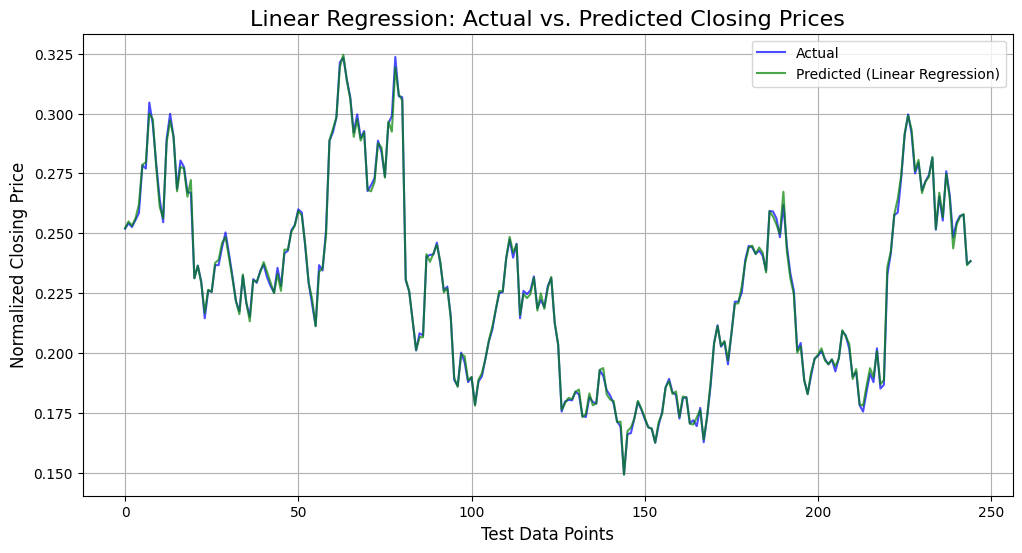

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(y_test.values, label='Actual', color='blue', alpha=0.7)
plt.plot(y_pred_linear, label='Predicted (Linear Regression)', color='green', alpha=0.7)
plt.title('Linear Regression: Actual vs. Predicted Closing Prices', fontsize=16)
plt.xlabel('Test Data Points', fontsize=12)
plt.ylabel('Normalized Closing Price', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

# plot_closing_price(data_cleaned)

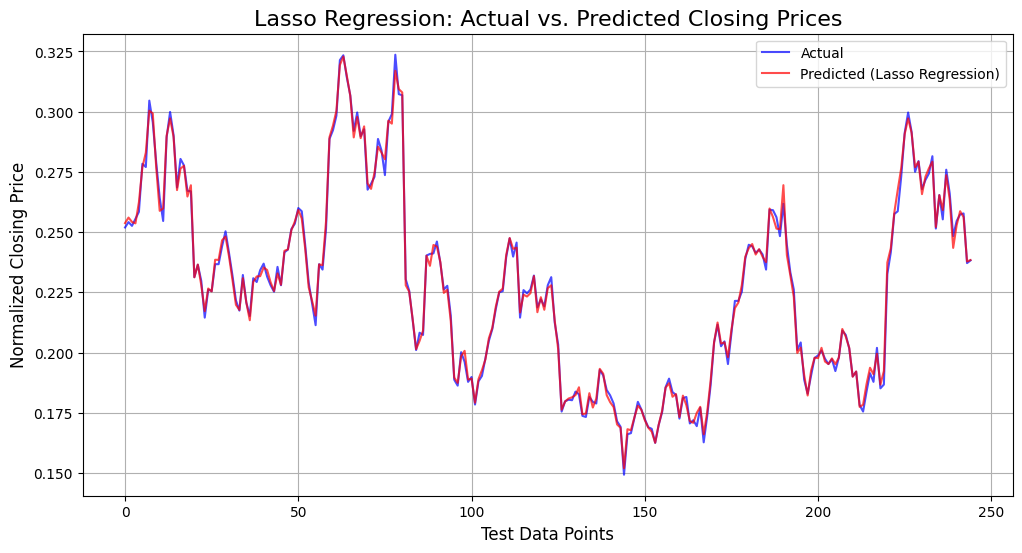

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(y_test.values, label='Actual', color='blue', alpha=0.7)
plt.plot(y_pred_lasso, label='Predicted (Lasso Regression)', color='red', alpha=0.7)
plt.title('Lasso Regression: Actual vs. Predicted Closing Prices', fontsize=16)
plt.xlabel('Test Data Points', fontsize=12)
plt.ylabel('Normalized Closing Price', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import joblib
linear_model_filename = 'linear_regression_model.pkl'
joblib.dump(linear_model, linear_model_filename)
print(f"Linear Regression model saved as {linear_model_filename}")

lasso_model_filename = 'lasso_regression_model.pkl'
joblib.dump(lasso_model, lasso_model_filename)
print(f"Lasso Regression model saved as {lasso_model_filename}")

Linear Regression model saved as linear_regression_model.pkl
Lasso Regression model saved as lasso_regression_model.pkl
